# Assignment 5 — Exploring the Latent Space of a Pretrained StyleGAN2 Model

This assignment explores how a pretrained StyleGAN2 model represents images in its latent space. We will generate two images from random latent vectors, interpolate between the vectors to create a smooth image transition, and then study how changing selected latent dimensions affects the generated image.

In [1]:
!nvidia-smi

Thu Sep 24 16:59:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Download NVIDIA StyleGAN2-ADA

We use NVIDIA's official StyleGAN2-ADA PyTorch implementation. This provides the code required to load and use a pretrained StyleGAN2 generator without training the model from scratch.

In [4]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
%cd stylegan2-ada-pytorch

fatal: destination path 'stylegan2-ada-pytorch' already exists and is not an empty directory.
/content/stylegan2-ada-pytorch


## 2. Set the Project Directory

The StyleGAN2-ADA repository has already been downloaded. This cell changes the current working directory to the repository so that the required files and pretrained model can be accessed easily.

In [5]:
%cd /content/stylegan2-ada-pytorch

/content/stylegan2-ada-pytorch


## 3. Verify the StyleGAN2 Repository

This cell lists the files and folders inside the StyleGAN2-ADA repository. It verifies that the NVIDIA implementation was downloaded correctly and that important files such as `generate.py`, `dnnlib`, and `torch_utils` are available.

In [6]:
!ls

calc_metrics.py  docker_run.sh	LICENSE.txt   style_mixing.py
dataset_tool.py  docs		metrics       torch_utils
dnnlib		 generate.py	projector.py  training
Dockerfile	 legacy.py	README.md     train.py


## 4. Install Required Libraries

StyleGAN2-ADA requires several supporting Python libraries. We install the required packages for model execution, image processing, and optimized operations.

In [7]:
!pip install click requests tqdm pyspng ninja imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 21.0 MB/s eta 0:00:00


## 5. Download the Pretrained FFHQ Model

Instead of training StyleGAN2 from scratch, we use NVIDIA's pretrained FFHQ model. The `ffhq.pkl` file contains the trained StyleGAN2 network that can generate realistic human face images from latent vectors.

In [10]:
!wget https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

--2026-09-24 17:07:31--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 143.204.160.57, 143.204.160.80, 143.204.160.50, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|143.204.160.57|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381624121 (364M) [binary/octet-stream]
Saving to: ‘ffhq.pkl’

ffhq.pkl            100%[===================>] 363.94M  30.1MB/s    in 5.1s    

2026-09-24 17:07:37 (71.2 MB/s) - ‘ffhq.pkl’ saved [381624121/381624121]



## 6. Verify the Pretrained Model

This cell checks whether the `ffhq.pkl` pretrained model was downloaded successfully and displays its file size.

In [11]:
!ls -lh ffhq.pkl

-rw-r--r-- 1 root root 364M Jan 17  2021 ffhq.pkl


In [29]:
import requests
url = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"

response = requests.get(url, stream=True)
response.raise_for_status()
with open("ffhq.pkl", "wb") as f:
  for chunk in response.iter_content(chunk_size=1024 * 1024):
    if chunk:
      f.write(chunk)

print("Download completed")


Download completed


## 7. Load the Pretrained StyleGAN2 Generator

We now load the pretrained `ffhq.pkl` model using PyTorch and place the generator on the available NVIDIA GPU.

The generator is represented by `G`. It takes a latent vector as input and produces a generated image as output. The model uses a 512-dimensional latent vector.

In [18]:
import torch
import pickle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
with open("ffhq.pkl", "rb") as f:
  G = pickle.load(f)["G_ema"].to(device)
print("Model loaded successfully!")
print("Latent dimension:", G.z_dim)

Using device: cuda
Model loaded successfully!
Latent dimension: 512


## 8. Select the Computing Device

This cell selects the NVIDIA CUDA GPU if it is available. Using the GPU makes StyleGAN2 image generation much faster than running the model on the CPU.

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



## 9. Generate Two Random Latent Vectors

A latent vector is a numerical representation used as input to the StyleGAN2 generator. The pretrained model uses a 512-dimensional latent vector.

We generate two independent random vectors, `z₁` and `z₂`. These two vectors represent two different points in the latent space and will produce two different generated images.

In [24]:
z1 = torch.randn([1, G.z_dim], device=device)
z2 = torch.randn([1, G.z_dim], device=device)

print("z1 shape:", z1.shape)
print("z2 shape:", z2.shape)

z1 shape: torch.Size([1, 512])
z2 shape: torch.Size([1, 512])


## 10. Create an Image Generation Function

This function converts a latent vector into an image using the pretrained StyleGAN2 generator.

The generator first produces an image tensor with values in the range [-1, 1]. The function converts these values into the standard image pixel range [0, 255] and changes the tensor format so that the image can be displayed and saved using Python image libraries.

`torch.no_grad()` is used because we are generating images and are not training the model.

In [25]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def generate_image(z):
    with torch.no_grad():
        img = G(
            z,
            None,
            truncation_psi=0.7,
            noise_mode='const'
        )

    # Convert from [-1, 1] to [0, 255]
    img = (img.clamp(-1, 1) + 1) * 127.5

    # Convert tensor format to image format
    img = img.permute(0, 2, 3, 1).to(torch.uint8)

    return img[0].cpu().numpy()

## 11. Generate the Two Initial Images

We now pass the two random latent vectors through the StyleGAN2 generator.

The first operation generates Image 1 from `z₁`, while the second generates Image 2 from `z₂`.

Therefore:

`z₁ → StyleGAN2 Generator → Image 1`

`z₂ → StyleGAN2 Generator → Image 2`

These are the two initial images required by the assignment.

In [26]:
img1 = generate_image(z1)
img2 = generate_image(z2)

print("Images generated successfully!")
print("Image 1 shape:", img1.shape)
print("Image 2 shape:", img2.shape)

Setting up PyTorch plugin "bias_act_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py:50: UserWarning: Failed to build CUDA kernels for bias_act. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py", line 48, in _init
    _plugin = custom_ops.get_plugin('bias_act_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module 

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Images generated successfully!
Image 1 shape: (1024, 1024, 3)
Image 2 shape: (1024, 1024, 3)


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

## 12. Display the Two Initial Images

This cell displays the two generated images side by side. The images correspond to the two randomly selected latent vectors `z₁` and `z₂`.

These images will also serve as the starting and ending points of our latent-space interpolation experiment.

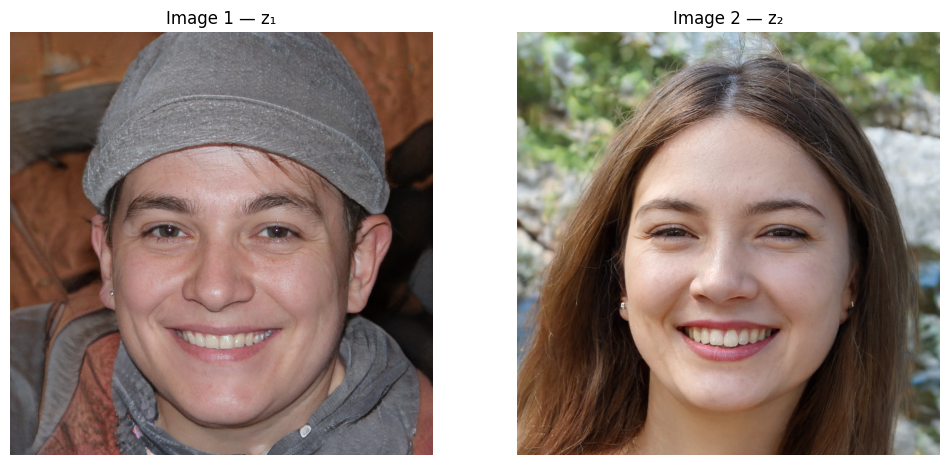

In [27]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Image 1 — z₁")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Image 2 — z₂")
plt.axis("off")

plt.show()

In [28]:
import os

os.makedirs("assignment5", exist_ok=True)

Image.fromarray(img1).save("assignment5/image_1_z1.png")
Image.fromarray(img2).save("assignment5/image_2_z2.png")

print("Images saved!")

Images saved!


In [40]:
import os

output_path = os.path.abspath("assignment5")

print("All assignment files are saved here:")
print(output_path)

print("\nFiles:")
for file in sorted(os.listdir(output_path)):
    print(os.path.join(output_path, file))

All assignment files are saved here:
/content/stylegan2-ada-pytorch/assignment5

Files:
/content/stylegan2-ada-pytorch/assignment5/image_1_z1.png
/content/stylegan2-ada-pytorch/assignment5/image_2_z2.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_00.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_01.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_02.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_03.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_04.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_05.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_06.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_07.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_08.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_09.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_10.png
/content/stylegan2-ada-pytorch/assignment5/interpolation_11.png
/content/stylegan2-ada-pytor

## 14. Linear Interpolation Between Two Latent Vectors

The main experiment is to smoothly move from the first latent vector `z₁` to the second latent vector `z₂`.

Linear interpolation is defined as:

`z(t) = (1 - t)z₁ + tz₂`

When `t = 0`, the result is exactly `z₁`.

When `t = 1`, the result is exactly `z₂`.

Values of `t` between 0 and 1 produce intermediate latent vectors. We generate 12 images so that there are approximately 10 intermediate images between the two original images.

In [30]:
num_images = 12

interpolated_images = []

for t in np.linspace(0, 1, num_images):
    z = (1 - t) * z1 + t * z2
    img = generate_image(z)
    interpolated_images.append(img)

print("Generated", len(interpolated_images), "interpolation images")

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


...

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

## 15. Display the Interpolation Sequence

This cell displays all generated images in their interpolation order. The first image corresponds to `z₁`, the last image corresponds to `z₂`, and the images between them are generated from intermediate latent vectors.

The purpose is to observe whether the generated face changes smoothly as we move through the latent space.

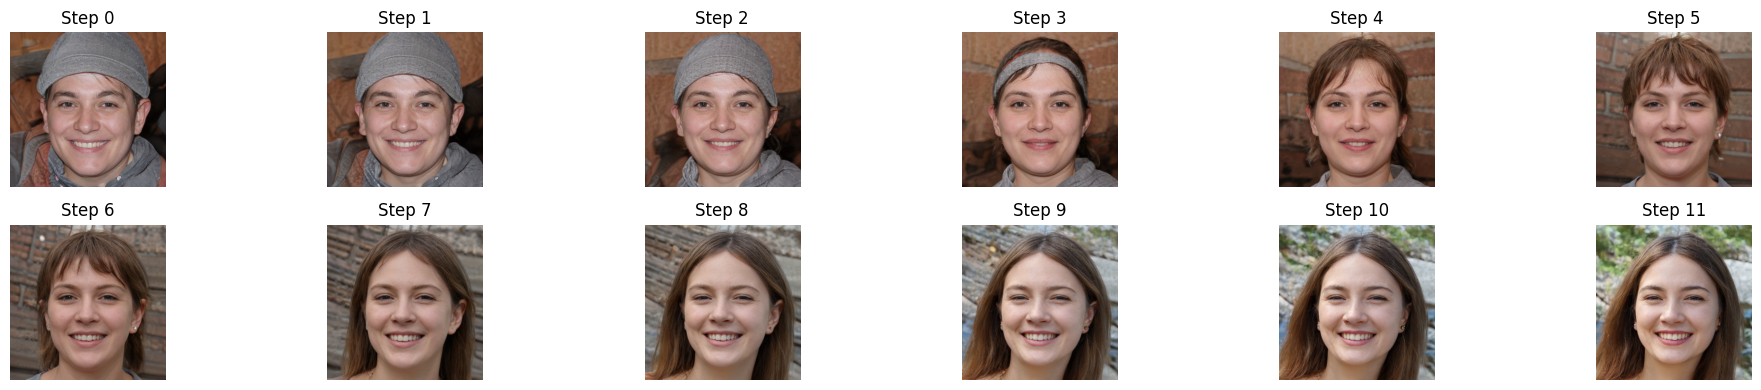

In [32]:
plt.figure(figsize=(20, 4))

for i, img in enumerate(interpolated_images):
    plt.subplot(2, 6, i + 1)
    plt.imshow(img)
    plt.title(f"Step {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 16. Save the Interpolation Images

Each generated intermediate image is saved separately as a PNG file. This allows us to inspect individual frames and use them to create the final image strip and GIF.

In [33]:
for i, img in enumerate(interpolated_images):
    Image.fromarray(img).save(
        f"assignment5/interpolation_{i:02d}.png"
    )

print("Interpolation images saved successfully!")

Interpolation images saved successfully!


## 17. Create an Image Strip

The interpolation images are combined horizontally into a single image strip.

The strip provides a clear visual representation of how the generated image changes from the first latent vector `z₁` to the second latent vector `z₂`.

In [34]:
imgs = [Image.fromarray(img) for img in interpolated_images]

width, height = imgs[0].size

strip = Image.new(
    "RGB",
    (width * len(imgs), height)
)

for i, img in enumerate(imgs):
    strip.paste(img, (i * width, 0))

strip.save("assignment5/interpolation_strip.png")

print("Image strip saved successfully!")

Image strip saved successfully!


## 18. Create a GIF of the Latent-Space Transition

The interpolation images are combined into an animated GIF.

The GIF shows the generated image changing gradually from the image produced by `z₁` to the image produced by `z₂`. This provides a visual demonstration of smooth movement through the latent space.

In [35]:
import imageio.v2 as imageio

imageio.mimsave(
    "assignment5/stylegan_interpolation.gif",
    interpolated_images,
    duration=0.3,
    loop=0
)

print("GIF saved successfully!")

GIF saved successfully!


## 19. Experiment by Changing One Latent Dimension

A latent vector contains 512 numerical dimensions. In this experiment, we keep the original latent vector `z₁` unchanged except for one dimension.

This allows us to observe whether changing a specific latent value produces a visible change in the generated image.

In [36]:
z_changed = z1.clone()

# Change only the first latent dimension
z_changed[0, 0] += 2.5

original_img = generate_image(z1)
changed_img = generate_image(z_changed)

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

## 20. Compare the Original and Modified Latent Vectors

The original image is generated using `z₁`, while the second image is generated after changing only one dimension of `z₁`.

By comparing the two images, we can observe whether the selected latent dimension affects visible characteristics of the generated face.

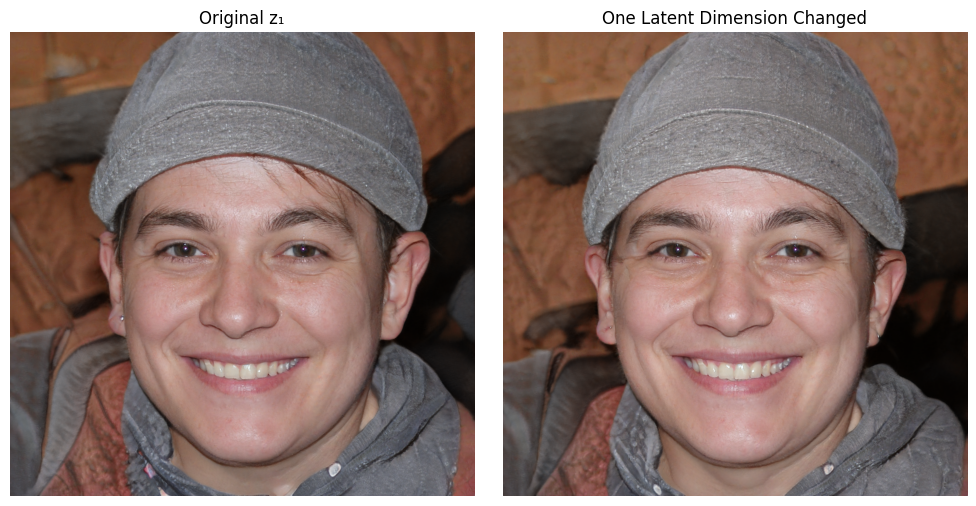

In [37]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original z₁")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(changed_img)
plt.title("One Latent Dimension Changed")
plt.axis("off")

plt.tight_layout()
plt.show()

## 21. Experiment by Changing Two Latent Dimensions

We now modify two dimensions of the original latent vector while keeping the remaining dimensions unchanged.

This experiment helps us observe whether modifying multiple latent values produces a larger or different visible change in the generated image.

In [38]:
z_changed_2 = z1.clone()

z_changed_2[0, 0] += 2.5
z_changed_2[0, 1] -= 2.0

changed_img_2 = generate_image(z_changed_2)

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

## 22. Compare Changes in the Latent Dimensions

This comparison shows the original image, the image after changing one latent dimension, and the image after changing two latent dimensions.

The purpose is to observe how modifications in the latent representation can affect visible characteristics of the generated image.

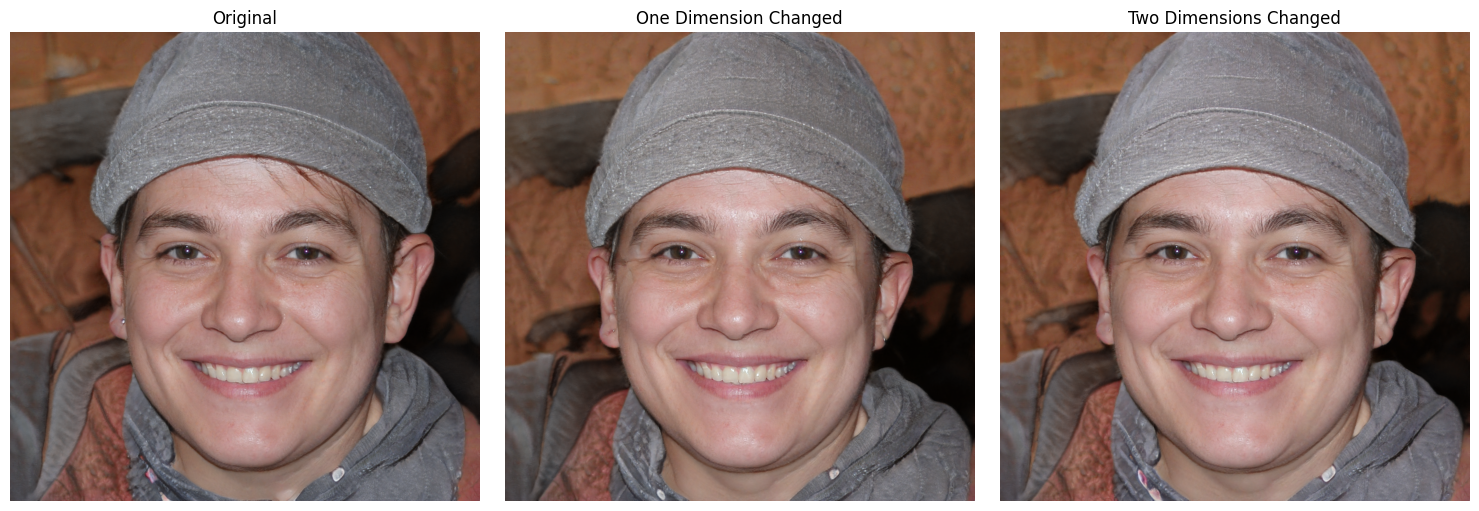

In [39]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(changed_img)
plt.title("One Dimension Changed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(changed_img_2)
plt.title("Two Dimensions Changed")
plt.axis("off")

plt.tight_layout()
plt.show()

## 23. Observation

During linear interpolation between the two latent vectors, the generated face changes gradually from the first image toward the second image rather than changing abruptly. This shows that StyleGAN2's latent space contains structured information that can produce smooth visual variations.

When one or two latent dimensions are changed, visible differences can also appear in the generated image. However, a single latent dimension does not necessarily represent only one specific feature; changing it may influence multiple visual characteristics of the image.



## 24. Conclusion

This experiment demonstrated how a pretrained StyleGAN2 model uses a latent vector to generate images. Linear interpolation between two latent vectors produced a smooth sequence of generated images, showing that meaningful visual variations can exist in the latent space. The latent-dimension experiment further showed that modifying values in the latent representation can change visible characteristics of the generated image.
